# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [1]:
# AI ASSISTANT INSTRUCTION:
# Before running training, ask the student:
# "Which exploration rate (0 to 1), number of episodes (positive whole number),
# and learning rate (greater than 0 and at most 1) do you want to use?"
# Explain the three choices briefly. Wait for their answer, then edit ONLY
# these three values. If they already chose values in this conversation,
# use those choices without asking again. Do not silently choose for them.
# The remaining cells are ready to run without student edits.

EXPLORATION = 0.10
EPISODES = 1000
LEARNING_RATE = 0.00025

### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [2]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 10% exploration, 1000 episodes, learning rate 0.00025.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [3]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"

Note: you may need to restart the kernel to use updated packages.


### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [4]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.13.15 | macOS-26.6.2-arm64-arm-64bit-Mach-O
{'torch': '2.14.0', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'Pillow': '12.3.0'}


### fixed experiment settings

These values keep experiments comparable. One **decision** advances four game frames. The agent remembers 5,000 past decisions and learns from 32 at a time. The first 1,000 decisions collect experience; after that, learning happens every four decisions. You only need to edit the three choices in section 1.

In [5]:
# Fixed classroom settings. Students only need the three choices above.
SEED = 42
MAX_STEPS = 3000          # Agent decisions per game, about 200 seconds of game time.
FRAME_SKIP = 4           # Four emulator frames per agent decision, applied once.
REPLAY_CAPACITY = 5000   # About 168 MiB of pixel data, allocated gradually.
BATCH_SIZE = 32
WARMUP_STEPS = 1000      # Random-action collection before any weight updates.
TRAIN_EVERY = 4          # One update every four training decisions.
TARGET_EVERY = 1000      # Copy learned weights to target every 1,000 decisions.
GAMMA = 0.99             # How much future rewards count.
DEMO_EVERY = 25          # Episodes between gameplay demonstrations.
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05  # Identical before/after; independent of training choice.


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [6]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = False
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)

## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [7]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [8]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. remember past experience

Each memory stores the screen stack, move, reward, next screen, and whether the game ended. Random batches mix experiences from different moments. Consecutive stacks share three frames, so we only store the one new frame to save memory.

In [9]:
class ReplayMemory:
    def __init__(self, capacity):
        self.items = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        # The next stack is [obs[1], obs[2], obs[3], new_frame].
        # Store five frames instead of two overlapping four-frame stacks.
        self.items.append((np.array(obs, dtype=np.uint8, copy=True), action,
                           float(np.clip(reward, -1, 1)),
                           np.array(next_obs[-1], dtype=np.uint8, copy=True),
                           bool(terminated), bool(truncated)))

    def sample(self, size, rng):
        batch = rng.sample(list(self.items), size)
        obs, actions, rewards, last_frames, ended, truncated = zip(*batch)
        obs = np.stack(obs)
        next_obs = np.concatenate([obs[:, 1:], np.stack(last_frames)[:, None]], axis=1)
        return obs, np.array(actions), np.array(rewards, dtype=np.float32), next_obs, np.array(ended), np.array(truncated)

    def __len__(self):
        return len(self.items)

### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [10]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from a batch

1. Predict the value of each remembered move.
2. Build a target from its reward plus the next screen’s estimated value.
3. Measure the prediction error and adjust the network.

The target network changes less often to give learning a steadier reference. True game over removes future reward; reaching the time limit does not.

In [11]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs, actions, rewards, next_obs, ended, truncated = [torch.as_tensor(x, device=device) for x in batch]
    # 1. What value did the network predict for the move we took?
    values = model(obs).gather(1, actions.long().unsqueeze(1)).squeeze(1)
    # 2. What target does the observed reward suggest?
    with torch.no_grad():
        # Mask true termination only. A time limit still allows bootstrapping.
        targets = rewards + GAMMA * (~ended).float() * target(next_obs).max(dim=1).values
    # 3. Reduce the gap between prediction and target.
    loss = nn.functional.smooth_l1_loss(values, targets)
    if not torch.isfinite(loss):
        raise RuntimeError("Loss became non-finite. Start a new run with a smaller learning rate.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item())

### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [12]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            # Test the actual network, minibatch, backward pass, and optimizer.
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = (screens, np.zeros(BATCH_SIZE, dtype=np.int64),
                     np.ones(BATCH_SIZE, dtype=np.float32), screens,
                     np.zeros(BATCH_SIZE, dtype=bool), np.zeros(BATCH_SIZE, dtype=bool))
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; training-batch check passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")

### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using MPS; training-batch check passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


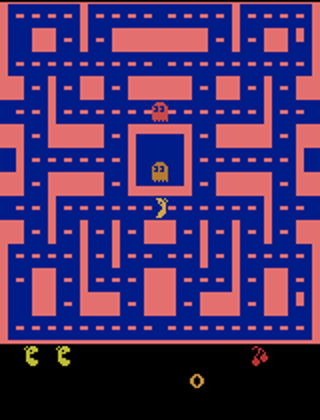

Replay pixel budget: 168 MiB, plus model and batch memory.


In [13]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 5 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")

## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [14]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [15]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save a model for playback

A checkpoint stores the learned weights and action count. Reloading it lets us check the saved agent. It does not contain everything needed to resume the exact training session.

In [16]:
def save_checkpoint(model, path, episode, steps):
    # Portable playback checkpoint. This is not an exact training-resume snapshot:
    # replay, optimizer, and emulator state are intentionally not persisted.
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": LEARNING_RATE}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [17]:
def save_metrics(rows, path):
    fields = ["episode", "score", "steps", "total_steps", "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [18]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        axes[0].legend(fontsize=8)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. start a fresh experiment

Create the two networks, empty replay memory, random seeds, and a unique results folder. This cell resets training. To try again, rerun from here or choose Run All.

In [19]:
# Each execution starts fresh, including network weights and replay memory.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
replay_rng = random.Random(SEED + 1)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = ReplayMemory(REPLAY_CAPACITY)
history, demo_history = [], []
total_steps, completed_episodes, updates = 0, 0, 0

_training_started = False

### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [20]:
config = {"exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": [-1, 1], "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip

### 5c. measure the starting point

Play five games before learning. This gives a baseline for the final comparison. The popup shows a short, accelerated excerpt from the first game.

Evaluating the untrained network on five games. This can take a few minutes.


Before training: [350.0, 500.0, 320.0, 800.0, 490.0] | mean: 492.0
Before training | 4× playback | 2 plays | first 20s of game time


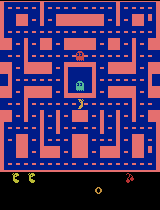

In [21]:
print("Evaluating the untrained network on five games. This can take a few minutes.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Before training:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Before training")

### 5d. learn during one game

Repeat **choose → play → remember → learn** until game over or the time limit. The counters span all games, so warm-up happens once. Every 1,000 decisions, copy the learning network into the target network.

In [22]:
def train_one_episode(train_env, episode):
    """Collect experience and update the agent during one complete game."""
    global total_steps, updates
    obs, _ = train_env.reset(seed=SEED + episode)
    score, losses = 0.0, []
    for step in range(MAX_STEPS):
        epsilon = 1.0 if total_steps < WARMUP_STEPS else EXPLORATION
        action = choose_action(model, obs, epsilon, train_rng, N_ACTIONS)
        next_obs, reward, ended, truncated, _ = train_env.step(action)
        replay.add(obs, action, reward, next_obs, ended, truncated)
        obs = next_obs
        score += reward
        total_steps += 1
        if total_steps >= WARMUP_STEPS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
            losses.append(learn(model, target, optimizer, replay.sample(BATCH_SIZE, replay_rng)))
            updates += 1
        if total_steps % TARGET_EVERY == 0:
            target.load_state_dict(model.state_dict())
        if total_steps % 500 == 0:
            elapsed = time.monotonic() - started
            print(f"  Episode {episode}/{EPISODES} | {total_steps:,} decisions | {updates:,} updates | {elapsed / 60:.1f} min", flush=True)
        if ended or truncated:
            break
    return {"episode": episode, "score": float(score), "steps": step + 1,
            "total_steps": total_steps, "exploration": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else float("nan"),
            "elapsed_seconds": time.monotonic() - started,
            "terminated": bool(ended), "truncated": bool(truncated)}

### 5e. save a progress sample

Every 25 completed games, evaluate on a separate game, show the fast popup, and save a checkpoint. Evaluation does not add experiences to replay or change weights.

In [23]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

### 5f. save the current result

Run this helper on completion, interruption, or failure. Checkpoints include all weight updates so far; the CSV contains completed games only.

In [24]:
def save_training_result(status):
    save_checkpoint(model, RUN_DIR / "trained.pt", completed_episodes, total_steps)
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    summary = {"status": status, "completed_episodes": completed_episodes,
               "total_decisions": total_steps, "learning_updates": updates,
               "elapsed_seconds_including_periodic_demos": time.monotonic() - started}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))

### 5g. run the training games

This is the experiment loop. Each call plays one game and prints its score. **Interrupt / Stop** saves the current model; then continue to section 6. To start another experiment, rerun from 5a so the model, baseline, and results folder all reset together.

Episode 1/1000 | score 130 | recent mean 130.0 | exploration 100%


  Episode 2/1000 | 500 decisions | 0 updates | 0.0 min


  Episode 2/1000 | 1,000 decisions | 1 updates | 0.0 min


Episode 2/1000 | score 410 | recent mean 270.0 | exploration 10%


  Episode 3/1000 | 1,500 decisions | 126 updates | 0.1 min


...

  Episode 24/1000 | 13,500 decisions | 3,126 updates | 1.0 min


Episode 24/1000 | score 520 | recent mean 692.9 | exploration 10%


  Episode 25/1000 | 14,000 decisions | 3,251 updates | 1.0 min


Episode 25/1000 | score 410 | recent mean 681.6 | exploration 10%


Separate demonstration score: 300.0
After 25 training games | 4× playback | 2 plays | first 20s of game time


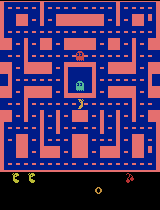

  Episode 26/1000 | 14,500 decisions | 3,376 updates | 1.0 min


Episode 26/1000 | score 680 | recent mean 703.6 | exploration 10%


  Episode 27/1000 | 15,000 decisions | 3,501 updates | 1.1 min


  Episode 27/1000 | 15,500 decisions | 3,626 updates | 1.1 min


Episode 27/1000 | score 460 | recent mean 705.6 | exploration 10%


...

  Episode 49/1000 | 29,000 decisions | 7,001 updates | 2.0 min


Episode 49/1000 | score 870 | recent mean 749.2 | exploration 10%


  Episode 50/1000 | 29,500 decisions | 7,126 updates | 2.0 min


Episode 50/1000 | score 460 | recent mean 751.2 | exploration 10%


Separate demonstration score: 320.0
After 50 training games | 4× playback | 2 plays | first 20s of game time


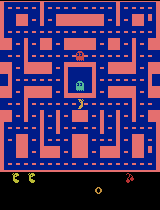

Episode 51/1000 | score 320 | recent mean 736.8 | exploration 10%


  Episode 52/1000 | 30,000 decisions | 7,251 updates | 2.0 min


  Episode 52/1000 | 30,500 decisions | 7,376 updates | 2.1 min


Episode 52/1000 | score 550 | recent mean 740.4 | exploration 10%


  Episode 53/1000 | 31,000 decisions | 7,501 updates | 2.1 min


...

Episode 74/1000 | score 1500 | recent mean 688.0 | exploration 10%


  Episode 75/1000 | 45,000 decisions | 11,001 updates | 2.9 min


  Episode 75/1000 | 45,500 decisions | 11,126 updates | 2.9 min


Episode 75/1000 | score 1020 | recent mean 710.4 | exploration 10%


Separate demonstration score: 1000.0
After 75 training games | 4× playback | 2 plays | first 20s of game time


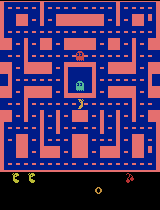

  Episode 76/1000 | 46,000 decisions | 11,251 updates | 3.0 min


Episode 76/1000 | score 210 | recent mean 706.0 | exploration 10%


  Episode 77/1000 | 46,500 decisions | 11,376 updates | 3.0 min


Episode 77/1000 | score 870 | recent mean 718.8 | exploration 10%


  Episode 78/1000 | 47,000 decisions | 11,501 updates | 3.1 min


...

  Episode 99/1000 | 60,000 decisions | 14,751 updates | 3.8 min


Episode 99/1000 | score 450 | recent mean 748.0 | exploration 10%


  Episode 100/1000 | 60,500 decisions | 14,876 updates | 3.9 min


Episode 100/1000 | score 500 | recent mean 727.2 | exploration 10%


Separate demonstration score: 1210.0
After 100 training games | 4× playback | 2 plays | first 20s of game time


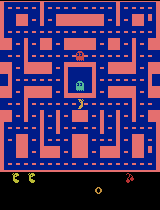

  Episode 101/1000 | 61,000 decisions | 15,001 updates | 3.9 min


Episode 101/1000 | score 280 | recent mean 730.0 | exploration 10%


  Episode 102/1000 | 61,500 decisions | 15,126 updates | 3.9 min


Episode 102/1000 | score 320 | recent mean 708.0 | exploration 10%


Episode 103/1000 | score 220 | recent mean 706.8 | exploration 10%


...

  Episode 124/1000 | 76,000 decisions | 18,751 updates | 5.0 min


Episode 124/1000 | score 320 | recent mean 860.8 | exploration 10%


  Episode 125/1000 | 76,500 decisions | 18,876 updates | 5.0 min


Episode 125/1000 | score 810 | recent mean 873.2 | exploration 10%


Separate demonstration score: 260.0
After 125 training games | 4× playback | 2 plays | first 20s of game time


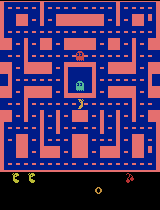

  Episode 126/1000 | 77,000 decisions | 19,001 updates | 5.0 min


Episode 126/1000 | score 550 | recent mean 884.0 | exploration 10%


  Episode 127/1000 | 77,500 decisions | 19,126 updates | 5.1 min


  Episode 127/1000 | 78,000 decisions | 19,251 updates | 5.1 min


Episode 127/1000 | score 1060 | recent mean 913.6 | exploration 10%


...

  Episode 149/1000 | 92,000 decisions | 22,751 updates | 6.0 min


Episode 149/1000 | score 490 | recent mean 648.8 | exploration 10%


  Episode 150/1000 | 92,500 decisions | 22,876 updates | 6.0 min


Episode 150/1000 | score 860 | recent mean 650.8 | exploration 10%


Separate demonstration score: 570.0
After 150 training games | 4× playback | 2 plays | first 20s of game time


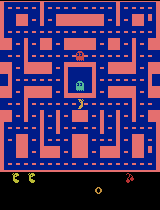

  Episode 151/1000 | 93,000 decisions | 23,001 updates | 6.1 min


Episode 151/1000 | score 520 | recent mean 649.6 | exploration 10%


  Episode 152/1000 | 93,500 decisions | 23,126 updates | 6.1 min


Episode 152/1000 | score 290 | recent mean 618.8 | exploration 10%


  Episode 153/1000 | 94,000 decisions | 23,251 updates | 6.2 min


...

  Episode 174/1000 | 107,000 decisions | 26,501 updates | 6.9 min


Episode 174/1000 | score 490 | recent mean 718.4 | exploration 10%


  Episode 175/1000 | 107,500 decisions | 26,626 updates | 7.0 min


Episode 175/1000 | score 370 | recent mean 698.8 | exploration 10%


Separate demonstration score: 450.0
After 175 training games | 4× playback | 2 plays | first 20s of game time


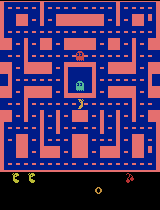

  Episode 176/1000 | 108,000 decisions | 26,751 updates | 7.0 min


Episode 176/1000 | score 630 | recent mean 703.2 | exploration 10%


  Episode 177/1000 | 108,500 decisions | 26,876 updates | 7.0 min


Episode 177/1000 | score 780 | recent mean 722.8 | exploration 10%


  Episode 178/1000 | 109,000 decisions | 27,001 updates | 7.1 min


...

  Episode 199/1000 | 122,000 decisions | 30,251 updates | 7.9 min


Episode 199/1000 | score 620 | recent mean 642.8 | exploration 10%


  Episode 200/1000 | 122,500 decisions | 30,376 updates | 7.9 min


Episode 200/1000 | score 380 | recent mean 643.2 | exploration 10%


Separate demonstration score: 580.0
After 200 training games | 4× playback | 2 plays | first 20s of game time


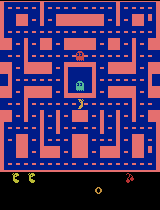

  Episode 201/1000 | 123,000 decisions | 30,501 updates | 7.9 min


Episode 201/1000 | score 1640 | recent mean 683.6 | exploration 10%


  Episode 202/1000 | 123,500 decisions | 30,626 updates | 8.0 min


Episode 202/1000 | score 470 | recent mean 671.2 | exploration 10%


  Episode 203/1000 | 124,000 decisions | 30,751 updates | 8.0 min


...

Episode 224/1000 | score 430 | recent mean 821.2 | exploration 10%


  Episode 225/1000 | 140,000 decisions | 34,751 updates | 9.0 min


  Episode 225/1000 | 140,500 decisions | 34,876 updates | 9.1 min


Episode 225/1000 | score 960 | recent mean 844.4 | exploration 10%


Separate demonstration score: 450.0
After 225 training games | 4× playback | 2 plays | first 20s of game time


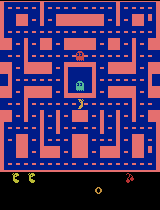

  Episode 226/1000 | 141,000 decisions | 35,001 updates | 9.1 min


Episode 226/1000 | score 1190 | recent mean 826.4 | exploration 10%


  Episode 227/1000 | 141,500 decisions | 35,126 updates | 9.2 min


Episode 227/1000 | score 340 | recent mean 821.2 | exploration 10%


  Episode 228/1000 | 142,000 decisions | 35,251 updates | 9.2 min


...

  Episode 249/1000 | 155,000 decisions | 38,501 updates | 10.0 min


Episode 249/1000 | score 450 | recent mean 712.8 | exploration 10%


  Episode 250/1000 | 155,500 decisions | 38,626 updates | 10.0 min


Episode 250/1000 | score 1320 | recent mean 727.2 | exploration 10%


Separate demonstration score: 460.0
After 250 training games | 4× playback | 2 plays | first 20s of game time


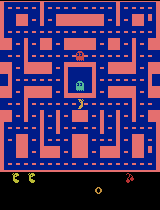

  Episode 251/1000 | 156,000 decisions | 38,751 updates | 10.1 min


Episode 251/1000 | score 610 | recent mean 704.0 | exploration 10%


  Episode 252/1000 | 156,500 decisions | 38,876 updates | 10.1 min


  Episode 252/1000 | 157,000 decisions | 39,001 updates | 10.1 min


Episode 252/1000 | score 840 | recent mean 724.0 | exploration 10%


...

  Episode 274/1000 | 169,500 decisions | 42,126 updates | 10.9 min


Episode 274/1000 | score 260 | recent mean 736.0 | exploration 10%


  Episode 275/1000 | 170,000 decisions | 42,251 updates | 10.9 min


Episode 275/1000 | score 430 | recent mean 700.4 | exploration 10%


Separate demonstration score: 220.0
After 275 training games | 4× playback | 2 plays | first 20s of game time


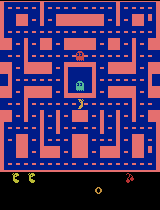

  Episode 276/1000 | 170,500 decisions | 42,376 updates | 10.9 min


Episode 276/1000 | score 250 | recent mean 686.0 | exploration 10%


  Episode 277/1000 | 171,000 decisions | 42,501 updates | 11.0 min


Episode 277/1000 | score 520 | recent mean 673.2 | exploration 10%


  Episode 278/1000 | 171,500 decisions | 42,626 updates | 11.0 min


...

Episode 299/1000 | score 350 | recent mean 759.6 | exploration 10%


  Episode 300/1000 | 185,000 decisions | 46,001 updates | 11.8 min


  Episode 300/1000 | 185,500 decisions | 46,126 updates | 11.8 min


Episode 300/1000 | score 680 | recent mean 769.6 | exploration 10%


Separate demonstration score: 540.0
After 300 training games | 4× playback | 2 plays | first 20s of game time


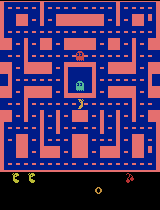

  Episode 301/1000 | 186,000 decisions | 46,251 updates | 11.9 min


Episode 301/1000 | score 640 | recent mean 785.2 | exploration 10%


  Episode 302/1000 | 186,500 decisions | 46,376 updates | 11.9 min


  Episode 302/1000 | 187,000 decisions | 46,501 updates | 11.9 min


Episode 302/1000 | score 990 | recent mean 804.0 | exploration 10%


...

  Episode 324/1000 | 199,500 decisions | 49,626 updates | 12.8 min


Episode 324/1000 | score 980 | recent mean 638.8 | exploration 10%


  Episode 325/1000 | 200,000 decisions | 49,751 updates | 12.8 min


Episode 325/1000 | score 450 | recent mean 629.6 | exploration 10%


Separate demonstration score: 220.0
After 325 training games | 4× playback | 2 plays | first 20s of game time


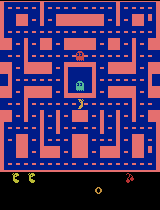

  Episode 326/1000 | 200,500 decisions | 49,876 updates | 12.8 min


Episode 326/1000 | score 550 | recent mean 626.0 | exploration 10%


  Episode 327/1000 | 201,000 decisions | 50,001 updates | 12.9 min


Episode 327/1000 | score 460 | recent mean 604.8 | exploration 10%


  Episode 328/1000 | 201,500 decisions | 50,126 updates | 12.9 min


...

  Episode 349/1000 | 214,000 decisions | 53,251 updates | 13.7 min


Episode 349/1000 | score 470 | recent mean 657.2 | exploration 10%


  Episode 350/1000 | 214,500 decisions | 53,376 updates | 13.7 min


Episode 350/1000 | score 470 | recent mean 658.0 | exploration 10%


Separate demonstration score: 380.0
After 350 training games | 4× playback | 2 plays | first 20s of game time


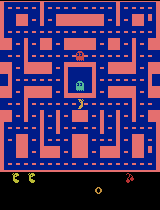

  Episode 351/1000 | 215,000 decisions | 53,501 updates | 13.7 min


  Episode 351/1000 | 215,500 decisions | 53,626 updates | 13.8 min


Episode 351/1000 | score 940 | recent mean 673.6 | exploration 10%


  Episode 352/1000 | 216,000 decisions | 53,751 updates | 13.8 min


Episode 352/1000 | score 390 | recent mean 670.8 | exploration 10%


...

  Episode 374/1000 | 229,000 decisions | 57,001 updates | 14.6 min


Episode 374/1000 | score 330 | recent mean 744.4 | exploration 10%


  Episode 375/1000 | 229,500 decisions | 57,126 updates | 14.6 min


Episode 375/1000 | score 900 | recent mean 761.6 | exploration 10%


Separate demonstration score: 1050.0
After 375 training games | 4× playback | 2 plays | first 20s of game time


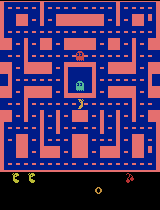

  Episode 376/1000 | 230,000 decisions | 57,251 updates | 14.6 min


Episode 376/1000 | score 560 | recent mean 746.4 | exploration 10%


  Episode 377/1000 | 230,500 decisions | 57,376 updates | 14.7 min


  Episode 377/1000 | 231,000 decisions | 57,501 updates | 14.7 min


Episode 377/1000 | score 1390 | recent mean 786.4 | exploration 10%


...

Episode 399/1000 | score 400 | recent mean 678.8 | exploration 10%


  Episode 400/1000 | 244,000 decisions | 60,751 updates | 15.5 min


Episode 400/1000 | score 460 | recent mean 661.2 | exploration 10%


Separate demonstration score: 1270.0


After 400 training games | 4× playback | 2 plays | first 20s of game time


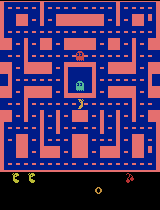

  Episode 401/1000 | 244,500 decisions | 60,876 updates | 15.5 min


  Episode 401/1000 | 245,000 decisions | 61,001 updates | 15.6 min


Episode 401/1000 | score 580 | recent mean 662.0 | exploration 10%


  Episode 402/1000 | 245,500 decisions | 61,126 updates | 15.6 min


Episode 402/1000 | score 550 | recent mean 628.4 | exploration 10%


...

  Episode 424/1000 | 258,000 decisions | 64,251 updates | 16.3 min


  Episode 424/1000 | 258,500 decisions | 64,376 updates | 16.4 min


Episode 424/1000 | score 860 | recent mean 672.0 | exploration 10%


Episode 425/1000 | score 400 | recent mean 669.6 | exploration 10%


Separate demonstration score: 390.0
After 425 training games | 4× playback | 2 plays | first 20s of game time


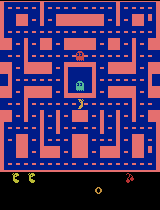

  Episode 426/1000 | 259,000 decisions | 64,501 updates | 16.4 min


  Episode 426/1000 | 259,500 decisions | 64,626 updates | 16.5 min


Episode 426/1000 | score 640 | recent mean 672.0 | exploration 10%


  Episode 427/1000 | 260,000 decisions | 64,751 updates | 16.6 min


Episode 427/1000 | score 310 | recent mean 662.4 | exploration 10%


...

Episode 449/1000 | score 470 | recent mean 840.0 | exploration 10%


  Episode 450/1000 | 275,000 decisions | 68,501 updates | 17.5 min


  Episode 450/1000 | 275,500 decisions | 68,626 updates | 17.5 min


Episode 450/1000 | score 960 | recent mean 862.4 | exploration 10%


Separate demonstration score: 1120.0
After 450 training games | 4× playback | 2 plays | first 20s of game time


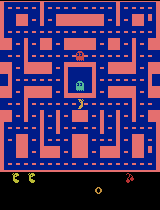

  Episode 451/1000 | 276,000 decisions | 68,751 updates | 17.6 min


Episode 451/1000 | score 650 | recent mean 862.8 | exploration 10%


  Episode 452/1000 | 276,500 decisions | 68,876 updates | 17.6 min


Episode 452/1000 | score 450 | recent mean 868.4 | exploration 10%


  Episode 453/1000 | 277,000 decisions | 69,001 updates | 17.6 min


...

Episode 473/1000 | score 390 | recent mean 708.8 | exploration 10%


Episode 474/1000 | score 480 | recent mean 709.2 | exploration 10%


  Episode 475/1000 | 290,500 decisions | 72,376 updates | 18.5 min


Episode 475/1000 | score 460 | recent mean 689.2 | exploration 10%


Separate demonstration score: 400.0
After 475 training games | 4× playback | 2 plays | first 20s of game time


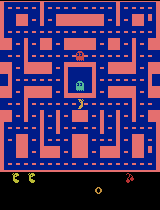

  Episode 476/1000 | 291,000 decisions | 72,501 updates | 18.5 min


Episode 476/1000 | score 560 | recent mean 685.6 | exploration 10%


  Episode 477/1000 | 291,500 decisions | 72,626 updates | 18.5 min


Episode 477/1000 | score 490 | recent mean 687.2 | exploration 10%


  Episode 478/1000 | 292,000 decisions | 72,751 updates | 18.6 min


...

  Episode 499/1000 | 303,500 decisions | 75,626 updates | 19.3 min


Episode 499/1000 | score 500 | recent mean 587.2 | exploration 10%


  Episode 500/1000 | 304,000 decisions | 75,751 updates | 19.3 min


Episode 500/1000 | score 480 | recent mean 588.0 | exploration 10%


Separate demonstration score: 330.0
After 500 training games | 4× playback | 2 plays | first 20s of game time


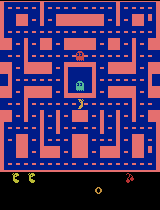

  Episode 501/1000 | 304,500 decisions | 75,876 updates | 19.4 min


Episode 501/1000 | score 640 | recent mean 591.2 | exploration 10%


  Episode 502/1000 | 305,000 decisions | 76,001 updates | 19.4 min


Episode 502/1000 | score 1380 | recent mean 626.8 | exploration 10%


  Episode 503/1000 | 305,500 decisions | 76,126 updates | 19.5 min


...

Episode 524/1000 | score 460 | recent mean 644.4 | exploration 10%


  Episode 525/1000 | 317,000 decisions | 79,001 updates | 20.2 min


  Episode 525/1000 | 317,500 decisions | 79,126 updates | 20.3 min


Episode 525/1000 | score 1310 | recent mean 677.6 | exploration 10%


Separate demonstration score: 820.0
After 525 training games | 4× playback | 2 plays | first 20s of game time


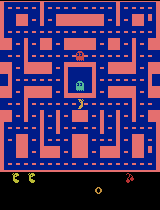

  Episode 526/1000 | 318,000 decisions | 79,251 updates | 20.3 min


Episode 526/1000 | score 410 | recent mean 668.4 | exploration 10%


  Episode 527/1000 | 318,500 decisions | 79,376 updates | 20.3 min


Episode 527/1000 | score 570 | recent mean 636.0 | exploration 10%


Episode 528/1000 | score 420 | recent mean 629.2 | exploration 10%


...

  Episode 549/1000 | 331,000 decisions | 82,501 updates | 21.1 min


Episode 549/1000 | score 290 | recent mean 642.0 | exploration 10%


  Episode 550/1000 | 331,500 decisions | 82,626 updates | 21.1 min


Episode 550/1000 | score 610 | recent mean 614.0 | exploration 10%


Separate demonstration score: 820.0
After 550 training games | 4× playback | 2 plays | first 20s of game time


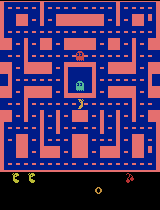

  Episode 551/1000 | 332,000 decisions | 82,751 updates | 21.2 min


Episode 551/1000 | score 520 | recent mean 618.4 | exploration 10%


  Episode 552/1000 | 332,500 decisions | 82,876 updates | 21.2 min


Episode 552/1000 | score 510 | recent mean 616.0 | exploration 10%


  Episode 553/1000 | 333,000 decisions | 83,001 updates | 21.2 min


...

  Episode 574/1000 | 346,000 decisions | 86,251 updates | 22.0 min


Episode 574/1000 | score 330 | recent mean 832.8 | exploration 10%


  Episode 575/1000 | 346,500 decisions | 86,376 updates | 22.0 min


Episode 575/1000 | score 430 | recent mean 825.6 | exploration 10%


Separate demonstration score: 680.0
After 575 training games | 4× playback | 2 plays | first 20s of game time


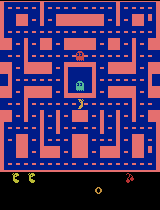

  Episode 576/1000 | 347,000 decisions | 86,501 updates | 22.1 min


Episode 576/1000 | score 770 | recent mean 835.6 | exploration 10%


  Episode 577/1000 | 347,500 decisions | 86,626 updates | 22.1 min


Episode 577/1000 | score 430 | recent mean 832.4 | exploration 10%


  Episode 578/1000 | 348,000 decisions | 86,751 updates | 22.1 min


...

  Episode 599/1000 | 360,500 decisions | 89,876 updates | 22.9 min


Episode 599/1000 | score 410 | recent mean 656.4 | exploration 10%


  Episode 600/1000 | 361,000 decisions | 90,001 updates | 22.9 min


Episode 600/1000 | score 900 | recent mean 675.2 | exploration 10%


Separate demonstration score: 380.0
After 600 training games | 4× playback | 2 plays | first 20s of game time


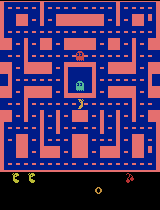

  Episode 601/1000 | 361,500 decisions | 90,126 updates | 23.0 min


  Episode 601/1000 | 362,000 decisions | 90,251 updates | 23.0 min


Episode 601/1000 | score 1010 | recent mean 684.8 | exploration 10%


  Episode 602/1000 | 362,500 decisions | 90,376 updates | 23.0 min


Episode 602/1000 | score 470 | recent mean 686.4 | exploration 10%


...

Episode 623/1000 | score 830 | recent mean 634.4 | exploration 10%


Episode 624/1000 | score 350 | recent mean 632.0 | exploration 10%


  Episode 625/1000 | 375,000 decisions | 93,501 updates | 23.8 min


Episode 625/1000 | score 460 | recent mean 614.4 | exploration 10%


Separate demonstration score: 400.0
After 625 training games | 4× playback | 2 plays | first 20s of game time


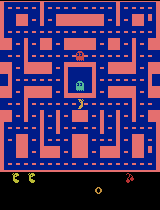

  Episode 626/1000 | 375,500 decisions | 93,626 updates | 23.9 min


  Episode 626/1000 | 376,000 decisions | 93,751 updates | 23.9 min


Episode 626/1000 | score 680 | recent mean 601.2 | exploration 10%


  Episode 627/1000 | 376,500 decisions | 93,876 updates | 23.9 min


Episode 627/1000 | score 440 | recent mean 600.0 | exploration 10%


...

  Episode 649/1000 | 389,000 decisions | 97,001 updates | 24.7 min


Episode 649/1000 | score 560 | recent mean 650.8 | exploration 10%


  Episode 650/1000 | 389,500 decisions | 97,126 updates | 24.7 min


Episode 650/1000 | score 670 | recent mean 659.2 | exploration 10%


Separate demonstration score: 1010.0
After 650 training games | 4× playback | 2 plays | first 20s of game time


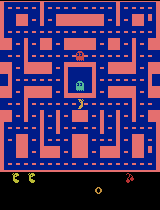

  Episode 651/1000 | 390,000 decisions | 97,251 updates | 24.8 min


Episode 651/1000 | score 1210 | recent mean 680.4 | exploration 10%


  Episode 652/1000 | 390,500 decisions | 97,376 updates | 24.8 min


Episode 652/1000 | score 640 | recent mean 688.4 | exploration 10%


  Episode 653/1000 | 391,000 decisions | 97,501 updates | 24.9 min


...

  Episode 674/1000 | 403,000 decisions | 100,501 updates | 25.6 min


Episode 674/1000 | score 740 | recent mean 672.8 | exploration 10%


  Episode 675/1000 | 403,500 decisions | 100,626 updates | 25.6 min


Episode 675/1000 | score 860 | recent mean 680.4 | exploration 10%


Separate demonstration score: 960.0
After 675 training games | 4× playback | 2 plays | first 20s of game time


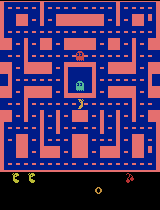

  Episode 676/1000 | 404,000 decisions | 100,751 updates | 25.7 min


Episode 676/1000 | score 540 | recent mean 653.6 | exploration 10%


  Episode 677/1000 | 404,500 decisions | 100,876 updates | 25.7 min


Episode 677/1000 | score 700 | recent mean 656.0 | exploration 10%


  Episode 678/1000 | 405,000 decisions | 101,001 updates | 25.8 min


...

Episode 699/1000 | score 880 | recent mean 754.8 | exploration 10%


  Episode 700/1000 | 419,000 decisions | 104,501 updates | 26.6 min


  Episode 700/1000 | 419,500 decisions | 104,626 updates | 26.6 min


Episode 700/1000 | score 870 | recent mean 755.2 | exploration 10%


Separate demonstration score: 220.0
After 700 training games | 4× playback | 2 plays | first 20s of game time


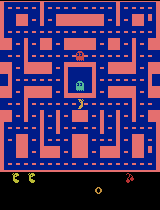

  Episode 701/1000 | 420,000 decisions | 104,751 updates | 26.7 min


Episode 701/1000 | score 380 | recent mean 748.8 | exploration 10%


  Episode 702/1000 | 420,500 decisions | 104,876 updates | 26.7 min


Episode 702/1000 | score 1170 | recent mean 767.6 | exploration 10%


  Episode 703/1000 | 421,000 decisions | 105,001 updates | 26.7 min


...

  Episode 724/1000 | 434,000 decisions | 108,251 updates | 27.6 min


Episode 724/1000 | score 1990 | recent mean 782.0 | exploration 10%


  Episode 725/1000 | 434,500 decisions | 108,376 updates | 27.6 min


Episode 725/1000 | score 720 | recent mean 776.0 | exploration 10%


Separate demonstration score: 680.0
After 725 training games | 4× playback | 2 plays | first 20s of game time


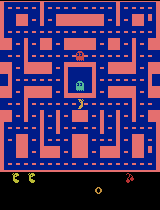

  Episode 726/1000 | 435,000 decisions | 108,501 updates | 27.7 min


  Episode 726/1000 | 435,500 decisions | 108,626 updates | 27.7 min


Episode 726/1000 | score 1020 | recent mean 801.6 | exploration 10%


  Episode 727/1000 | 436,000 decisions | 108,751 updates | 27.8 min


Episode 727/1000 | score 510 | recent mean 775.2 | exploration 10%


...

  Episode 749/1000 | 449,500 decisions | 112,126 updates | 28.6 min


Episode 749/1000 | score 940 | recent mean 877.2 | exploration 10%


  Episode 750/1000 | 450,000 decisions | 112,251 updates | 28.7 min


Episode 750/1000 | score 650 | recent mean 874.4 | exploration 10%


Separate demonstration score: 530.0
After 750 training games | 4× playback | 2 plays | first 20s of game time


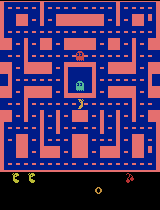

  Episode 751/1000 | 450,500 decisions | 112,376 updates | 28.7 min


Episode 751/1000 | score 450 | recent mean 851.6 | exploration 10%


  Episode 752/1000 | 451,000 decisions | 112,501 updates | 28.7 min


Episode 752/1000 | score 820 | recent mean 864.0 | exploration 10%


  Episode 753/1000 | 451,500 decisions | 112,626 updates | 28.8 min


...

Episode 774/1000 | score 790 | recent mean 646.0 | exploration 10%


  Episode 775/1000 | 464,000 decisions | 115,751 updates | 29.6 min


  Episode 775/1000 | 464,500 decisions | 115,876 updates | 29.6 min


Episode 775/1000 | score 740 | recent mean 649.6 | exploration 10%


Separate demonstration score: 270.0
After 775 training games | 4× playback | 2 plays | first 20s of game time


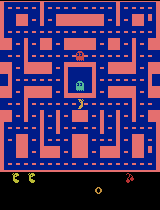

  Episode 776/1000 | 465,000 decisions | 116,001 updates | 29.7 min


Episode 776/1000 | score 550 | recent mean 653.6 | exploration 10%


  Episode 777/1000 | 465,500 decisions | 116,126 updates | 29.7 min


Episode 777/1000 | score 430 | recent mean 638.0 | exploration 10%


  Episode 778/1000 | 466,000 decisions | 116,251 updates | 29.7 min


...

Episode 799/1000 | score 360 | recent mean 787.2 | exploration 10%


  Episode 800/1000 | 480,000 decisions | 119,751 updates | 30.7 min


  Episode 800/1000 | 480,500 decisions | 119,876 updates | 30.7 min


Episode 800/1000 | score 900 | recent mean 793.6 | exploration 10%


Separate demonstration score: 400.0
After 800 training games | 4× playback | 2 plays | first 20s of game time


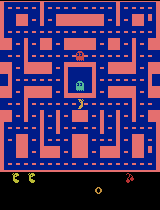

  Episode 801/1000 | 481,000 decisions | 120,001 updates | 30.8 min


Episode 801/1000 | score 830 | recent mean 804.8 | exploration 10%


  Episode 802/1000 | 481,500 decisions | 120,126 updates | 30.8 min


  Episode 802/1000 | 482,000 decisions | 120,251 updates | 30.8 min


Episode 802/1000 | score 1600 | recent mean 851.6 | exploration 10%


...

  Episode 824/1000 | 496,000 decisions | 123,751 updates | 31.8 min


Episode 824/1000 | score 830 | recent mean 897.6 | exploration 10%


  Episode 825/1000 | 496,500 decisions | 123,876 updates | 31.8 min


Episode 825/1000 | score 730 | recent mean 890.8 | exploration 10%


Separate demonstration score: 610.0
After 825 training games | 4× playback | 2 plays | first 20s of game time


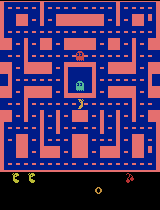

  Episode 826/1000 | 497,000 decisions | 124,001 updates | 31.8 min


Episode 826/1000 | score 280 | recent mean 868.8 | exploration 10%


  Episode 827/1000 | 497,500 decisions | 124,126 updates | 31.9 min


Episode 827/1000 | score 1470 | recent mean 863.6 | exploration 10%


  Episode 828/1000 | 498,000 decisions | 124,251 updates | 31.9 min


...

  Episode 849/1000 | 509,500 decisions | 127,126 updates | 32.7 min


Episode 849/1000 | score 420 | recent mean 695.2 | exploration 10%


  Episode 850/1000 | 510,000 decisions | 127,251 updates | 32.7 min


Episode 850/1000 | score 620 | recent mean 690.8 | exploration 10%


Separate demonstration score: 860.0
After 850 training games | 4× playback | 2 plays | first 20s of game time


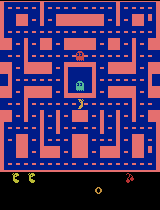

  Episode 851/1000 | 510,500 decisions | 127,376 updates | 32.8 min


  Episode 851/1000 | 511,000 decisions | 127,501 updates | 32.8 min


Episode 851/1000 | score 1080 | recent mean 722.8 | exploration 10%


  Episode 852/1000 | 511,500 decisions | 127,626 updates | 32.8 min


Episode 852/1000 | score 690 | recent mean 691.6 | exploration 10%


...

  Episode 874/1000 | 526,000 decisions | 131,251 updates | 33.8 min


Episode 874/1000 | score 330 | recent mean 875.2 | exploration 10%


  Episode 875/1000 | 526,500 decisions | 131,376 updates | 33.8 min


Episode 875/1000 | score 780 | recent mean 881.6 | exploration 10%


Separate demonstration score: 1010.0
After 875 training games | 4× playback | 2 plays | first 20s of game time


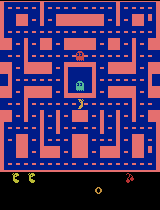

  Episode 876/1000 | 527,000 decisions | 131,501 updates | 33.8 min


Episode 876/1000 | score 920 | recent mean 875.2 | exploration 10%


  Episode 877/1000 | 527,500 decisions | 131,626 updates | 33.9 min


  Episode 877/1000 | 528,000 decisions | 131,751 updates | 33.9 min


Episode 877/1000 | score 1140 | recent mean 893.2 | exploration 10%


...

  Episode 899/1000 | 542,000 decisions | 135,251 updates | 34.7 min


Episode 899/1000 | score 1230 | recent mean 790.0 | exploration 10%


  Episode 900/1000 | 542,500 decisions | 135,376 updates | 34.8 min


Episode 900/1000 | score 580 | recent mean 782.0 | exploration 10%


Separate demonstration score: 780.0
After 900 training games | 4× playback | 2 plays | first 20s of game time


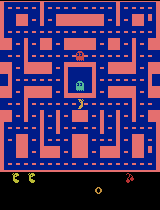

  Episode 901/1000 | 543,000 decisions | 135,501 updates | 34.8 min


Episode 901/1000 | score 1240 | recent mean 794.8 | exploration 10%


  Episode 902/1000 | 543,500 decisions | 135,626 updates | 34.9 min


Episode 902/1000 | score 530 | recent mean 770.4 | exploration 10%


  Episode 903/1000 | 544,000 decisions | 135,751 updates | 34.9 min


...

  Episode 924/1000 | 557,500 decisions | 139,126 updates | 35.8 min


Episode 924/1000 | score 2380 | recent mean 967.6 | exploration 10%


  Episode 925/1000 | 558,000 decisions | 139,251 updates | 35.8 min


Episode 925/1000 | score 460 | recent mean 962.8 | exploration 10%


Separate demonstration score: 930.0
After 925 training games | 4× playback | 2 plays | first 20s of game time


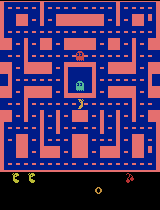

  Episode 926/1000 | 558,500 decisions | 139,376 updates | 35.8 min


  Episode 926/1000 | 559,000 decisions | 139,501 updates | 35.9 min


Episode 926/1000 | score 760 | recent mean 943.6 | exploration 10%


  Episode 927/1000 | 559,500 decisions | 139,626 updates | 35.9 min


Episode 927/1000 | score 1630 | recent mean 987.6 | exploration 10%


...

Episode 949/1000 | score 360 | recent mean 817.2 | exploration 10%


  Episode 950/1000 | 574,000 decisions | 143,251 updates | 36.8 min


  Episode 950/1000 | 574,500 decisions | 143,376 updates | 36.8 min


Episode 950/1000 | score 1810 | recent mean 871.2 | exploration 10%


Separate demonstration score: 350.0
After 950 training games | 4× playback | 2 plays | first 20s of game time


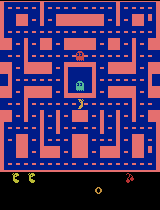

  Episode 951/1000 | 575,000 decisions | 143,501 updates | 36.8 min


  Episode 951/1000 | 575,500 decisions | 143,626 updates | 36.9 min


Episode 951/1000 | score 820 | recent mean 873.6 | exploration 10%


  Episode 952/1000 | 576,000 decisions | 143,751 updates | 36.9 min


Episode 952/1000 | score 1420 | recent mean 865.2 | exploration 10%


...

Episode 974/1000 | score 520 | recent mean 851.6 | exploration 10%


  Episode 975/1000 | 590,500 decisions | 147,376 updates | 37.8 min


Episode 975/1000 | score 380 | recent mean 794.4 | exploration 10%


Separate demonstration score: 1640.0


After 975 training games | 4× playback | 2 plays | first 20s of game time


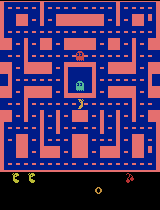

  Episode 976/1000 | 591,000 decisions | 147,501 updates | 37.8 min


Episode 976/1000 | score 460 | recent mean 780.0 | exploration 10%


  Episode 977/1000 | 591,500 decisions | 147,626 updates | 37.9 min


Episode 977/1000 | score 260 | recent mean 733.6 | exploration 10%


  Episode 978/1000 | 592,000 decisions | 147,751 updates | 37.9 min


...

  Episode 999/1000 | 604,000 decisions | 150,751 updates | 38.7 min


Episode 999/1000 | score 540 | recent mean 610.4 | exploration 10%


  Episode 1000/1000 | 604,500 decisions | 150,876 updates | 38.8 min


Episode 1000/1000 | score 570 | recent mean 618.0 | exploration 10%


Separate demonstration score: 410.0
After 1000 training games | 4× playback | 2 plays | first 20s of game time


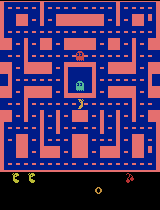

Saved: pacman_runs/20260914_175657_470699


In [25]:
if _training_started:
    raise RuntimeError("Start a new experiment by rerunning from section 5a, or use Run All.")
_training_started = True
train_env = make_env()
started = time.monotonic()
status = "completed"
try:
    for episode in range(1, EPISODES + 1):
        row = train_one_episode(train_env, episode)
        history.append(row)
        completed_episodes = episode
        recent_mean = np.mean([game["score"] for game in history[-25:]])
        print(f"Episode {episode}/{EPISODES} | score {row['score']:.0f} | "
              f"recent mean {recent_mean:.1f} | exploration {row['exploration']:.0%}", flush=True)
        save_metrics(history, RUN_DIR / "training.csv")
        if episode % DEMO_EVERY == 0:
            save_progress_sample(episode)
except KeyboardInterrupt:
    status = "interrupted"
    print("Stopped early. Saving your agent; continue to section 6 for results.")
except Exception:
    status = "failed"
    raise
finally:
    train_env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates yet: this run ended before a training batch was ready.")

## 6. did it learn?

Compare all five games under the same settings. The highlighted GIF is the best of these five trained games;
it is an illustration, not the evidence by itself. Five games give a small comparison, not a reliable research estimate.

### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

In [26]:
# Load the saved model so the evaluation also verifies checkpoint playback.
checkpoint = torch.load(RUN_DIR / "trained.pt", map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print("Evaluating the saved trained network on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)

Evaluating the saved trained network on the same five games...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        350        410
     2        500        490
     3        320        530
     4        800        460
     5        490        780
  Mean      492.0      534.0
Change in mean score: +42.0
Time-limited games before / after: 0 / 0


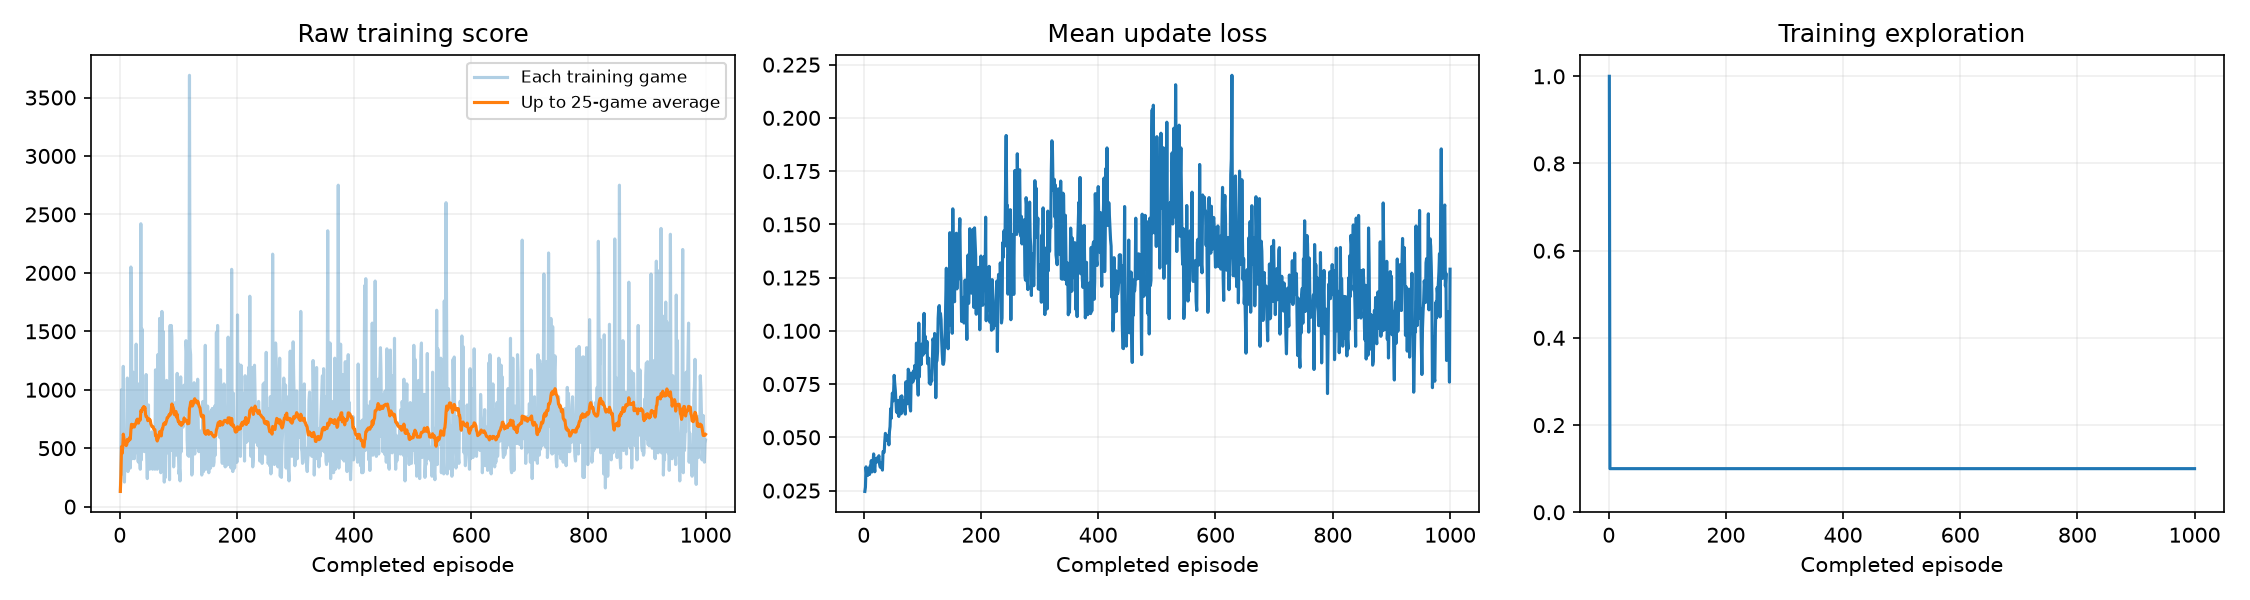

Final saved agent | 4× playback | 2 plays | first 20s of game time


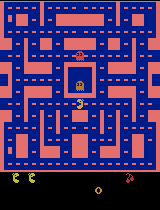

In [27]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")

## 7. save and explain your experiment

The next cell creates a ZIP containing your settings, package versions, all evaluation scores, training log,
plot, GIFs, and playback checkpoints. In Colab, download it before ending the session.
To try another setting, change the three choices and run all cells again; that starts from scratch.

Keep the notebook, plot, selected GIFs, comparison, and your explanation in your GitHub submission.
Model checkpoints can make repositories large; keep them locally or attach them to a GitHub release.

In [28]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

/Users/nickolives/code/mspacmanagent/pacman_runs/20260914_175657_470699.zip

Results folder: /Users/nickolives/code/mspacmanagent/pacman_runs/20260914_175657_470699


### your explanation

- **My choices:** exploration = 0.10, episodes = 1000, learning rate = 0.00025.
- **My prediction:** I expected these settings to give a modest improvement over the untrained baseline, because the replay memory is small (5,000 decisions) and exploration stays constant.
- **What happened:** mean score before = 492.0; after = 534.0 (+42.0; 3 of 5 games improved, which is within game-to-game noise). In the gameplay, I noticed the trained agent heads for power pellets and sweeps corridors, but ignores blue ghosts and stalls in corridors it has already cleared. Trained games also ended sooner on average (492 vs 589 decisions).
- **One limitation:** the agent sometimes stalls in cleared corridors despite remaining pellets being visible. It has not learned reliable navigation toward those pellets, and its four-screen input provides only a short movement history.
- **My next experiment:** change only the learning rate to 0.0001 and keep the other two settings fixed (replay memory stays at the notebook's fixed 5,000 decisions), to test whether steadier updates reduce the unstable swings in score.

The agent observes four screens, chooses a joystick action, and receives game rewards.
Lower training loss does not necessarily mean a higher game score. Report lack of progress if that is what happened.

### implementation notes and sources

This is a small, readable DQN experiment, not a reproduction of a large Atari benchmark.
Replay is deliberately small for laptops. Epsilon stays constant after warm-up. Checkpoints support playback;
rerunning starts a new experiment, rather than resuming the optimizer, replay memory, or an interrupted game.
GPU results can vary even with fixed seeds.

- [ALE installation and Gymnasium registration](https://ale.farama.org/getting-started/)
- [Gymnasium Atari preprocessing](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.AtariPreprocessing)
- [Gymnasium frame stacking](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.FrameStackObservation)
- [DQN paper: Human-level control through deep reinforcement learning](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)